<a href="https://colab.research.google.com/github/Rouliiane/2026_Intro_Python/blob/main/part-I/1.4-matplotlib-and-xarray-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.4-matplotlib-and-xarray-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [52]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Run the shared setup cell below first — exercises 1 to 8 use the synthetic station records it builds, and exercises 6, 9, and 11 also draw on its random-number generator. Label every axis with its unit.

Exercise 18 works on a real global-temperature record, and the last four exercises work differently: each shows a figure made from a real dataset and asks you to rebuild it. Get as close as you can, and read the hints one at a time rather than all at once.

In [53]:
# Pre-supplied: run this first. Three synthetic station records and a humidity series,
# standing in for a year of daily weather observations.
import numpy as np
import matplotlib.pyplot as plt

#exercices 20-23

In [54]:
rng = np.random.default_rng(1)

In [55]:
days = np.arange(366)                                  # day of year, 2024 (a leap year)
seasonal_celsius = -np.cos(2 * np.pi * days / 366) * 10.0

In [56]:
valley_celsius = 6.0 + seasonal_celsius + rng.normal(0, 1.5, size=366)
ridge_celsius = valley_celsius - 6.5                   # ~1000 m higher
mountain_celsius = valley_celsius - 18.0               # ~2800 m higher

In [57]:
# humidity peaks about a month after the coldest day, so it lags temperature
rh_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 30) / 366) + rng.normal(0, 3.0, size=366)

In [58]:
print(valley_celsius.shape, rh_percent.shape)

(366,) (366,)


## Exercise 1: Placing axes by hand

Build a 7 × 3 inch figure with two axes positioned with `fig.add_axes`: a main panel covering
roughly the left two-thirds, and a smaller one in the upper right. Plot the valley station's
whole year in the main panel and January alone (`days[:31]`) in the small one. Label the axes of
both, and give the small panel a title.

In [59]:
# Your solution here

## Exercise 2: A grid of panels

With `plt.subplots(2, 2, figsize=(9, 5))`, give each of the three station records and the
humidity series its own panel. Print the shape of the axes array, label every panel with its
quantity and unit, give each a title, and pack the figure with `tight_layout`.

In [60]:
# Your solution here

## Exercise 3: Telling series apart without colour

Plot all three station records on one axes so that they stay distinguishable printed in black
and white: all three in black, one solid, one dashed, one dotted. Then add every thirtieth point
of the valley record as circular markers with no line joining them. Add a legend.

In a second figure, draw the valley record as it would read at twelve elevations, from 0 m to
2200 m every 200 m, cooling by 6.5 °C per 1000 m, and name each curve in a legend. The default
colour cycle has ten entries, so two of the twelve curves repeat earlier colours. Say in a comment
which ones, and make them distinguishable by drawing every curve after the tenth dashed.

In [61]:
# Your solution here

## Exercise 4: Ticks, gridlines, and axis limits

Plot the valley record with a tick at the first day of every month, labelled with the month's
initial (`"J"`, `"F"`, `"M"`, ...). The month lengths of 2024 are below; each month starts on the
running total of the lengths of the months before it, and an array's `.cumsum()` gives running
totals (1.3). Add major y ticks every 5 °C and minor ones every 1 °C, with a solid major grid and
a dotted minor grid.

In a second figure, show July and August only, taking the x-limits from the start days you
computed, and set the y-limits to leave 1 °C of space above and below the data in those two
months.

```python
month_days = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])   # 2024
```

In [62]:
# Your solution here

## Exercise 5: Annotate the largest jump

Find the largest one-day warming in the valley record: the day on which the temperature rose most
from the day before. The change from each day to the next is one slice of the record minus
another, offset by one day, and `np.argmax` of that change locates the jump. Print the day of year
of the warmer day and the size of the jump, mark the warmer day on the plot with `ax.annotate` and
an arrow, and add a plain `ax.text` label in an empty part of the figure.

In [63]:
# Your solution here

## Exercise 6: A parametric plot

The setup cell's humidity series lags temperature by about 30 days. Build a second one that lags
by 90 days (below), average the valley record and both humidity series into twelve monthly means
with `[:360].reshape(12, 30).mean(axis=1)`, and draw both loops on one axes: humidity against
temperature, a marker at each month, and a legend saying which lag is which. In a comment, say how
the loop changes as the lag grows, and what the twelve points would look like with no lag at all.

```python
rh_lag90_percent = 68.0 + 12.0 * np.cos(2 * np.pi * (days - 90) / 366) + rng.normal(0, 3.0, size=366)
```

In [64]:
# Your solution here

## Exercise 7: Comparing two distributions

Draw the distributions of daily temperature at the valley and mountain stations as two histograms
on one axes. Give them the same bin edges — `bins` also accepts an array of edges, which
`np.linspace` can build to span both records — and draw them semi-transparent with `alpha=0.6`, so
the overlap stays visible. Add a legend and label both axes. In a comment, say how the two
distributions differ, and why.

In [65]:
# Your solution here

## Exercise 8: Monthly means as bars

Average the valley record into twelve monthly means with `[:360].reshape(12, 30).mean(axis=1)`
and draw them as a bar chart, one bar per month, with the month's initial as each tick label.
Colour the freezing months (mean below 0 °C) with the hex code `"#2c7bb6"` and the others with the
grey level `"0.6"` — `color` also accepts a list with one colour per bar. On a second axes beside
it, compare the annual means of the three stations with `barh`. Label the value axis with its unit
in both.

In [66]:
# Your solution here

## Exercise 9: One field, four ways

Build the small gridded field below, then draw it four times in a 2 × 2 figure: with `imshow`
(row 0 is the southernmost latitude, so make it appear at the bottom), with `pcolormesh` using
the coordinates as cell centres, with `contourf` using 8 levels, and with `pcolormesh` and
`shading="flat"`. The last needs the cell *edges*: one more value than there are centres along
each axis, starting half a grid step before the first centre. It should come out identical to the
second panel. Label the `imshow` panel's axes in grid index and the other three in degrees, give
each panel a labelled colorbar, and save the figure as `_files/field.svg`.

```python
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)      # ascending: south -> north
field_celsius = 6.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))
```

In [67]:
# Your solution here

## Exercise 10: A vector field

Build the synthetic wind field below — a simple rotation, like a cyclone seen from above — and
draw it two ways in a 1 × 2 figure. On the left, `quiver` at every third grid point, over
`contour` lines of the wind speed. On the right, `streamplot` coloured by wind speed, with a
labelled colorbar whose unit, metres per second, is written with mathtext (1.4.5) so the
exponent is a real superscript. Label the axes in km.

```python
x_km = np.linspace(-100, 100, 25)
y_km = np.linspace(-100, 100, 25)
xx_km, yy_km = np.meshgrid(x_km, y_km)
u_ms = -yy_km / 8.0
v_ms = xx_km / 8.0
```

In [68]:
# Your solution here

## Exercise 11: Fix the map

The cell below draws a temperature anomaly field — the departure from a long-term mean, in °C, on
a 0.5° grid over the Alps — and breaks most of the checklist in 1.4.12. First list every practice
it breaks, as comments. Then redraw the same data so that it passes all of them.

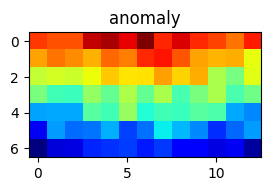

In [69]:
# Pre-supplied: a map that breaks most of the checklist.
# Leave this cell as it is -- write the corrected version in the next one.
anomaly_lon = np.linspace(5.0, 11.0, 13)
anomaly_lat = np.linspace(45.0, 48.0, 7)                     # ascending: south -> north
anomaly_celsius = ((46.5 - anomaly_lat)[:, None] * 1.5
                   + 0.4 * np.sin(anomaly_lon)[None, :]
                   + rng.normal(0, 0.3, size=(7, 13)))

fig, ax = plt.subplots(figsize=(3, 2))
ax.imshow(anomaly_celsius, cmap="jet")
ax.set_title("anomaly")
plt.show()

In [70]:
# Your solution here

## Exercise 12: Build a labelled DataArray

From `data = np.arange(12.0).reshape(3, 4)`, build an xarray DataArray with dimensions
`("lat", "lon")`, latitude coordinates `[46.0, 46.5, 47.0]`, longitude coordinates
`[6.0, 6.5, 7.0, 7.5]`, and a `units` attribute of `"degC"`. Print its dims and its units.

In [71]:
# Your solution here

## Exercise 13: Select, reduce, and subtract

Build the small Dataset below, then:

1. Print the spatial mean of the first day (by position) and the time mean at each longitude
   along 47.0° N (by label).
2. Select the grid point nearest 46.8° N, 6.3° E, and print its coordinates and its ten values.
3. Subtract each day's spatial mean — the mean over `lat` and `lon` — from the field. Print the
   dims of the result, and its spatial mean on the first day, which should be zero up to rounding.

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})
```

In [72]:
# Your solution here

## Exercise 14: Monthly anomalies, two ways

Build the one-year daily temperature DataArray below and subtract its annual mean to get each
day's anomaly. Compute the monthly mean anomaly with `resample`, and print the calendar month
(1–12) whose mean anomaly is largest. Then compute the monthly mean anomaly again with
`groupby("time.month")`, and print the largest difference between the two sets of twelve values.
In a comment, say why the two agree here, and what would differ between them for a ten-year
record.

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
n = time.size; doy = np.arange(n)
t = 5 + -np.cos(2 * np.pi * doy / n) * 10 + rng.normal(0, 1.5, n)
da = xr.DataArray(t, dims="time", coords={"time": time}, attrs={"units": "degC"})
```

In [73]:
# Your solution here

## Exercise 15: Round-trip through netCDF

Build a Dataset holding one 1D temperature variable, `t2m`, with a `units` attribute. Write it to
`_files/series.nc`, reopen it with `open_dataset`, and print the variable names and the recovered
units.

In [74]:
# Your solution here

## Exercise 16: What transform does

Rebuild the DataArray `da` from exercise 12 and draw it twice, side by side, on
`ccrs.EqualEarth()` maps cropped with `set_extent([5, 9, 45, 48], crs=ccrs.PlateCarree())` and
with `cfeature.BORDERS` added: once with `pcolormesh(..., transform=ccrs.PlateCarree())`, and
once with `transform` left out. Give the first panel a labelled colorbar. In a comment, say where
the field in the second panel went, and why no error was raised.

In [75]:
# Your solution here

## Exercise 17: Choosing a projection

Each figure described below needs a map. For each, choose a projection from 1.4.13 and draw the
empty map — land, ocean, and coastline, cropped with `set_extent` where the figure covers less
than the globe. Draw the three as panels of one figure; each panel needs its own projection, so
create each axes with `fig.add_subplot`. Justify each choice in a comment of one or two sentences.

1. The extent of Arctic sea ice in September. `ccrs.NorthPolarStereo()` is the northern
   counterpart of `SouthPolarStereo`.
2. How much of each continent is covered by tropical forest, for a reader who will compare the
   areas by eye.
3. A warm anomaly spreading through the Southern Ocean into the Atlantic, Indian, and Pacific
   basins, for a figure whose point is that the Southern Ocean links all three.

In [76]:
# Your solution here

## Exercise 18: NASA's real global-temperature record

The file cached below is NASA GISS's monthly global-mean surface temperature anomaly (°C,
relative to a 1951–1980 baseline), one row per year since 1880, one column per calendar month.
A handful of recent months are still missing, marked `***`.

Wrap the twelve month columns in an xarray `DataArray` with dims `("year", "month")` and a `units`
attribute, then draw two figures: the annual mean as a line against year, and the full
`(year, month)` array with xarray's own `.plot()`. In a comment, compare what the warming trend
looks like read month by month against the single annual line.

In [77]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/nasa_gistemp_global_temp_anomaly.csv",
    known_hash="sha256:6cfa44e7bbacd9b12cb10bdd64b3182c2735fa3f3a95688e1f7bc8e5dfcece93",
    fname="nasa_gistemp_global_temp_anomaly.csv",
    path=pooch.os_cache("mlees"),
)

In [78]:
# Your solution here
# Hint: load the file with
#       np.genfromtxt(path, skip_header=1, delimiter=",", names=True,
#                     missing_values="***", filling_values=np.nan)
#       -- names=True reads the header row, so the columns are data["Year"], data["Jan"], ...
# Hint: np.column_stack((data["Jan"], data["Feb"], ..., data["Dec"])) puts the twelve month
#       columns side by side as one (year, month) array
# Hint: the coordinates are data["Year"] and np.arange(1, 13)
# Hint: .mean(dim="month") skips the missing months on its own
# Hint: .plot() on the 2D DataArray draws a pcolormesh, and labels the colorbar from the
#       long_name and units attributes

## Replicating plots

The four exercises below each show a figure built from a real dataset and ask you to rebuild it
as closely as you can. The data arrive through a pre-supplied `pooch` cell; everything after that
is yours.

Work towards the target one element at a time — get the data onto the axes first, then the
coordinates, then the colours, then the labels — rather than trying to write the whole cell in
one go.

## Exercise 19: Global surface air temperature and its zonal mean

The three files cached below hold one snapshot of surface air temperature from the
[NCEP/NCAR atmospheric reanalysis 1](https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html),
as plain numpy arrays: `lon` (192 longitudes), `lat` (94 latitudes, running north to south), and
`temp_kelvin`, the field itself with shape `(94, 192)` — **in kelvin**.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-global-temperature.png" alt="A filled contour map of global surface air temperature in magma colours with a white dashed contour at minus ten degrees, beside a line plot of the zonal mean against latitude" width="100%">

<em>The figure to replicate. Left: the field as filled contours, with a single white contour drawn
at −10 °C. Right: the zonal mean — the average along longitude — against latitude.</em>


Rebuild it, and say in a comment which hemisphere's winter this snapshot was taken in, and how
the zonal mean tells you.

In [79]:
# Pre-supplied: download the three arrays and cache them locally.
import pooch

In [80]:
base_url = "https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/"

In [81]:
path_lon = pooch.retrieve(
    url=base_url + "ncep_global_temp_lon.npy",
    known_hash="sha256:eaf54b88dd89279d3034da17fe8470dc2c841bf9fa89b2aa741dacff9c326cdb",
    fname="ncep_global_temp_lon.npy",
    path=pooch.os_cache("mlees"),
)
path_lat = pooch.retrieve(
    url=base_url + "ncep_global_temp_lat.npy",
    known_hash="sha256:af1f438080460e1fca4583b2ec19b44285a3d3776e4d21b8da9b6e162906c88a",
    fname="ncep_global_temp_lat.npy",
    path=pooch.os_cache("mlees"),
)
path_temp = pooch.retrieve(
    url=base_url + "ncep_global_temp_kelvin.npy",
    known_hash="sha256:e040ca257334708b43e86398e09a5669fcf051179ecf5dcd278f758d67beed20",
    fname="ncep_global_temp_kelvin.npy",
    path=pooch.os_cache("mlees"),
)

In [82]:
# Your solution here
# Hint: np.load each file, then subtract 273.15 to go from kelvin to degrees celsius
# Hint: plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [5, 1.5]})
#       -- width_ratios is what makes the left panel wider than the right one
# Hint: the left panel is contourf with cmap="magma", levels=np.linspace(-30, 40, 15) and
#       extend="both", with contour at levels=[-10] and colors="w" on top; matplotlib dashes a
#       contour at a negative level on its own, which is where the dashed white line comes from
# Hint: the right panel is the mean along longitude, np.nanmean(temp_celsius, axis=1), plotted
#       against latitude -- so the temperature goes on the x-axis
# Hint: label both panels and the colorbar, and finish with plt.tight_layout()

## Exercise 20: Historic significant earthquakes

The file cached below is NOAA's catalog of significant earthquakes, reaching back to 2150 BCE:
one row per event, tab-separated, 47 columns. The four you need are at positions 8
(`FOCAL_DEPTH`, km), 9 (`EQ_PRIMARY`, magnitude), 20 (`LATITUDE`) and 21 (`LONGITUDE`).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-scatter.png" alt="A scatter plot of earthquake longitude against latitude, coloured by the base-10 logarithm of focal depth and sized by magnitude" width="100%">

<em>The figure to replicate: every event as one point, coloured by the base-10 logarithm of its
focal depth and sized by its magnitude. No coastline is drawn — the plate boundaries are the
data.</em>


Rebuild it, and in a comment name the feature of the Earth that the points trace out.

In [83]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/signif.txt.tsv",
    known_hash="sha256:f27e00d335f64ffaf437e74a8efb54f9154d40b417ff93fefb0fd64856e6d345",
    fname="signif.txt.tsv",
    path=pooch.os_cache("mlees"),
)

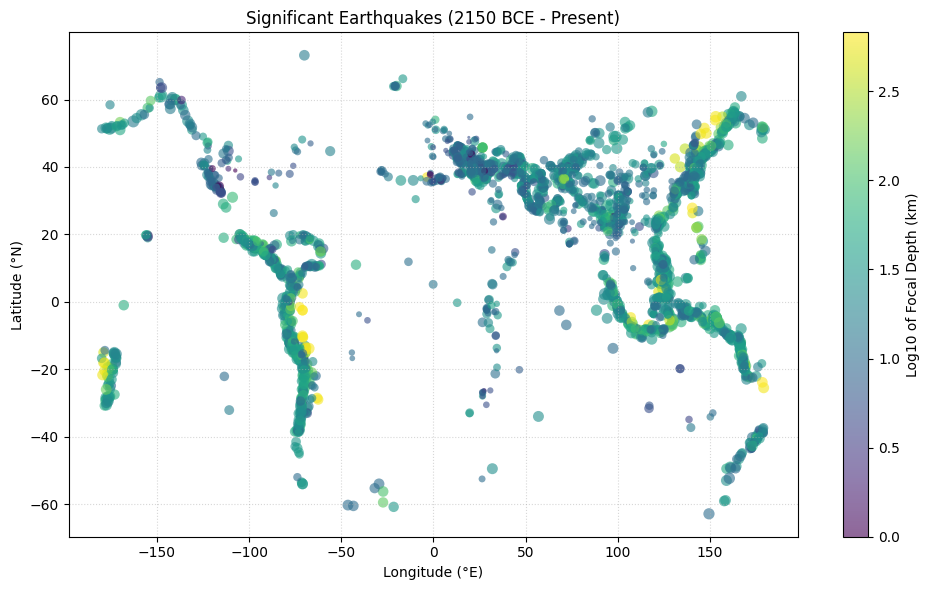

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Charger les données avec le délimiteur tabulation
# Le fichier contient de nombreuses colonnes vides ou manquantes, np.genfromtxt gère cela par défaut avec delimiter="\t"
arr = np.genfromtxt(path, delimiter="\t", skip_header=1)

# Extraire les colonnes requises par leur position
# 8: FOCAL_DEPTH, 9: EQ_PRIMARY, 20: LATITUDE, 21: LONGITUDE
depth = arr[:, 8]
mag = arr[:, 9]
lat = arr[:, 20]
lon = arr[:, 21]

# Créer un masque pour garder uniquement les lignes valides :
# - profondeur > 0 et magnitude > 0
# - latitude et longitude ne sont pas NaN
mask = (depth > 0) & (mag > 0) & (~np.isnan(lat)) & (~np.isnan(lon))

filtered_depth = depth[mask]
filtered_mag = mag[mask]
filtered_lat = lat[mask]
filtered_lon = lon[mask]

# Création de la figure
fig, ax = plt.subplots(figsize=(10, 6))

# Tracer les points : couleur par log10(profondeur) et taille par magnitude au carré
sc = ax.scatter(
    filtered_lon,
    filtered_lat,
    c=np.log10(filtered_depth),
    s=filtered_mag ** 2,
    cmap="viridis",
    alpha=0.6,
    edgecolors="none"
)

# Ajouter les éléments de style
cbar = fig.colorbar(sc, label="Log10 of Focal Depth (km)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Significant Earthquakes (2150 BCE - Present)")
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# Commentaire sur les structures tracées par les séismes :
# Les points dessinent les limites des plaques tectoniques terrestres (zones de subduction, dorsales, etc.).

## Exercise 21: Antarctic sea ice, summer against winter

Two real snapshots of Antarctic sea ice concentration from NOAA/NSIDC are cached below, as
`path_winter` (1 August 2017) and `path_summer` (31 December 2017). Each holds
`seaice_conc_cdr`, the ice concentration as a fraction from 0 to 1, on a south polar
stereographic grid — its coordinates are 2D `latitude`/`longitude` arrays rather than simple 1D
dimensions, so xarray's own `.plot()` will not label it cleanly.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-seaice.png" alt="Two south polar stereographic maps of Antarctic sea ice concentration, one in austral winter with a wide ice ring and one in austral summer with much less ice" width="100%">

<em>The figure to replicate: the same field on the same projection at two dates, with the land drawn
in grey beneath the ice and one colorbar shared by both panels.</em>


Rebuild it, and say which date shows more ice.

In [85]:
# Pre-supplied: download the data files and cache them locally.
import pooch

path_winter = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    known_hash="sha256:1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7",
    fname="seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    path=pooch.os_cache("mlees"),
)
path_summer = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    known_hash="sha256:309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66",
    fname="seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    path=pooch.os_cache("mlees"),
)

In [86]:
# Your solution here
# Hint: open each file with xr.open_dataset and select the single time step with .isel(time=0)
# Hint: the valid concentration range is 0-1; a few cells carry flag values above 1
#       (land, coastal, missing) -- mask them out first with da.where(da <= 1)
# Hint: build a figure with two ccrs.SouthPolarStereo() axes:
#       plt.subplots(1, 2, subplot_kw={"projection": ccrs.SouthPolarStereo()})
# Hint: ax.set_extent([-180, 180, -90, -55], ccrs.PlateCarree()) crops each axes to the
#       Southern Ocean instead of the whole hemisphere
# Hint: since latitude/longitude are 2D, plot with
#       ax.pcolormesh(ds["longitude"], ds["latitude"], masked, transform=ccrs.PlateCarree())
#       rather than xarray's own .plot()
# Hint: pass vmin=0 and vmax=1 to both pcolormesh calls, so a colour means the same
#       concentration in both panels and one colorbar can serve both
# Hint: add cfeature.LAND under the data and gridlines; fig.colorbar(pcm, ax=axes, label=...)
#       takes the whole array of axes and draws one colorbar for both panels

## Exercise 22: The 2014 earthquakes over North America

The file cached below is the real USGS earthquake catalog for 2014 — one row per event
worldwide, with latitude, longitude, depth and magnitude in columns 1 to 4. The target figure
keeps the whole catalog and lets the map extent do the selecting, so what you see is a window
onto a global dataset rather than one cropped to North America in advance.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-map.png" alt="A Robinson-projection map of North America with state boundaries, lakes and rivers, and earthquake locations coloured by depth" width="90%">

<em>The figure to replicate: magnitude 4 and above, on a Robinson projection cropped to North and
Central America, over land, ocean, lake, river and state-boundary features.</em>


Rebuild it.

In [87]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

In [88]:
# Your solution here
# Hint: load the four numeric columns with
#       np.genfromtxt(path, delimiter=",", skip_header=1, usecols=(1, 2, 3, 4))
#       -- usecols skips the text columns (time, place, ...) mixed in with the numbers
# Hint: keep mag >= 4 and depth_km > 0 (a few events are recorded at exactly 0 km, which
#       np.log10 cannot take); combine the two conditions into one mask with & ("and")
# Hint: fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Robinson()})
# Hint: ax.set_extent([-140, -60, 12, 70], ccrs.PlateCarree()) crops to the window shown
# Hint: the features are cfeature.LAND, cfeature.OCEAN, cfeature.LAKES, cfeature.RIVERS and
#       cfeature.STATES; add_feature takes edgecolor, facecolor and linewidth, and STATES
#       reads better in gray at a thin linewidth
# Hint: ax.scatter(longitude, latitude, transform=ccrs.PlateCarree(),
#                  c=np.log10(depth_km), s=mag ** 2)
#       -- transform tells cartopy the coordinates are plain lon/lat, not already projected
# Hint: finish with ax.gridlines, a labelled colorbar, and a title